In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from girsanov_uq.utils.utils import compute_derivative_check, compute_relative_cumulant_error
import warnings
warnings.filterwarnings("ignore")


In [ ]:
data_fit = np.load('./data_muller_brown/reweighting_aggregate.npz')
probs = np.concatenate([data_fit['ams_probabilities']], axis=0)
scores = np.concatenate([data_fit['all_scores']], axis=0)
fims = np.concatenate([data_fit['all_fims']], axis=0)




In [ ]:
probs_0_9d_0 = np.load('./data_muller_brown/0.9d_0_ref_probs.npy')
probs_0_9d_1 = np.load('./data_muller_brown/0.9d_1_ref_probs.npy')
probs_0_9d_2 = np.load('./data_muller_brown/0.9d_2_ref_probs.npy')
probs_0_9d_3 = np.load('./data_muller_brown/0.9d_3_ref_probs.npy')
probs_0_9d_4 = np.load('./data_muller_brown/0.9d_4_ref_probs.npy')
probs_0_95d_0 = np.load('./data_muller_brown/0.95d_0_ref_probs.npy')
probs_0_95d_1 = np.load('./data_muller_brown/0.95d_1_ref_probs.npy')
probs_0_95d_2 = np.load('./data_muller_brown/0.95d_2_ref_probs.npy')
probs_0_95d_3 = np.load('./data_muller_brown/0.95d_3_ref_probs.npy')
probs_0_95d_4 = np.load('./data_muller_brown/0.95d_4_ref_probs.npy')
probs_1_05d_0 = np.load('./data_muller_brown/1.05d_0_ref_probs.npy')
probs_1_05d_1 = np.load('./data_muller_brown/1.05d_1_ref_probs.npy')
probs_1_05d_2 = np.load('./data_muller_brown/1.05d_2_ref_probs.npy')
probs_1_05d_3 = np.load('./data_muller_brown/1.05d_3_ref_probs.npy')
probs_1_05d_4 = np.load('./data_muller_brown/1.05d_4_ref_probs.npy')
probs_1_1d_0 = np.load('./data_muller_brown/1.1d_0_ref_probs.npy')
probs_1_1d_1 = np.load('./data_muller_brown/1.1d_1_ref_probs.npy')
probs_1_1d_2 = np.load('./data_muller_brown/1.1d_2_ref_probs.npy')
probs_1_1d_3 = np.load('./data_muller_brown/1.1d_3_ref_probs.npy')
probs_1_1d_4 = np.load('./data_muller_brown/1.1d_4_ref_probs.npy')

In [ ]:
theta_0 = [-200,-100, -170, 15, 10, 0 ,0 ,0 ,0]
N_desc = scores.shape[2]
delta_theta = np.zeros(N_desc)

samples_0 = [[0,probs],[-0.1*theta_0[0], probs_0_9d_0], [-0.05*theta_0[0], probs_0_95d_0], [0.05*theta_0[0], probs_1_05d_0], [0.1*theta_0[0], probs_1_1d_0]]
samples_1 = [[0,probs], [-0.1*theta_0[1], probs_0_9d_1], [-0.05*theta_0[1], probs_0_95d_1], [0.05*theta_0[1], probs_1_05d_1], [0.1*theta_0[1], probs_1_1d_1]]
samples_2 = [[0,probs], [-0.1*theta_0[2], probs_0_9d_2], [-0.05*theta_0[2], probs_0_95d_2], [0.05*theta_0[2], probs_1_05d_2], [0.1*theta_0[2], probs_1_1d_2]]
samples_3 = [[0,probs], [-0.1*theta_0[3], probs_0_9d_3], [-0.05*theta_0[3], probs_0_95d_3], [0.05*theta_0[3], probs_1_05d_3], [0.1*theta_0[3], probs_1_1d_3]]
samples_4 = [[0,probs], [-0.1*theta_0[4], probs_0_9d_4], [-0.05*theta_0[4], probs_0_95d_4], [0.05*theta_0[4], probs_1_05d_4], [0.1*theta_0[4], probs_1_1d_4]]
samples_ref = [[0,probs]]

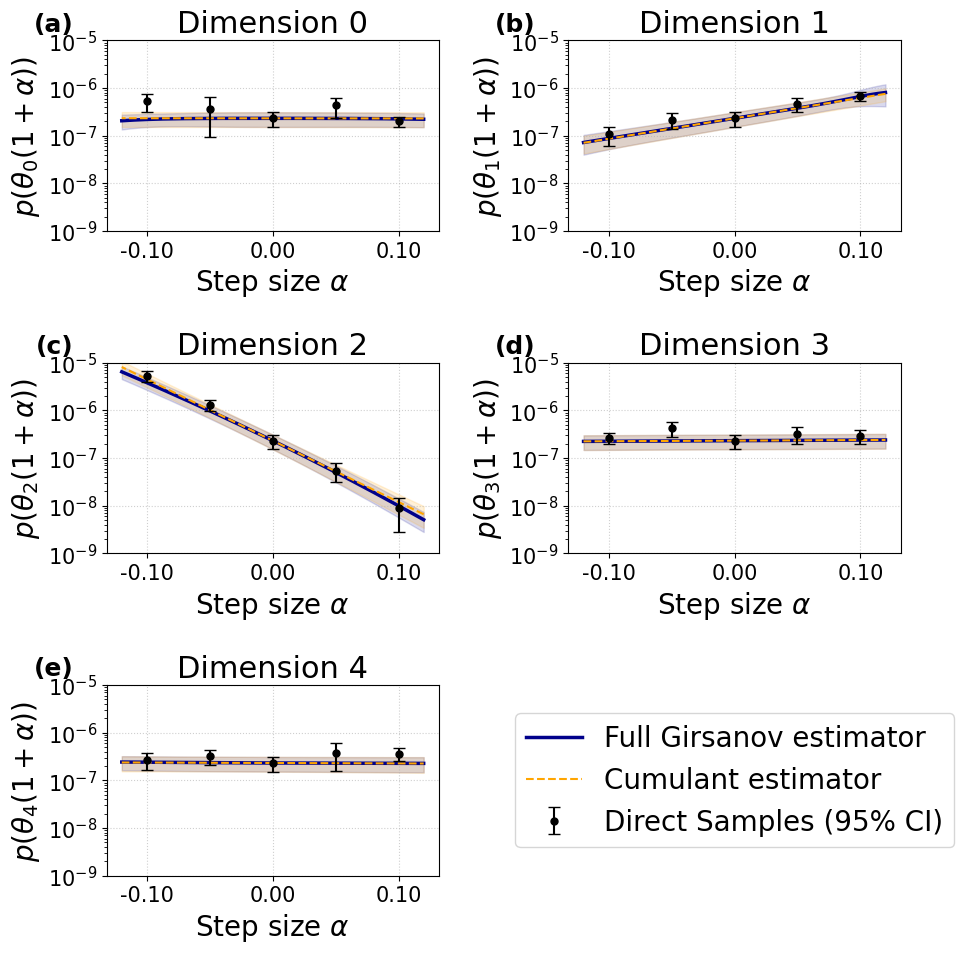

In [ ]:


from matplotlib.pyplot import axes


n_dims = 5
fig_main = plt.figure(figsize=(10, 10))
grid = fig_main.add_gridspec(3, 2)
axes_flat = [
    fig_main.add_subplot(grid[0, 0]),
    fig_main.add_subplot(grid[0, 1]),
    fig_main.add_subplot(grid[1, 0]),
    fig_main.add_subplot(grid[1, 1]),
    fig_main.add_subplot(grid[2, 0]),
]
legend_ax = fig_main.add_subplot(grid[2, 1])
legend_ax.axis('off')
legend_handles = None
legend_labels = None
labels = ['(a)', '(b)', '(c)', '(d)', '(e)']
samples_by_dim = [samples_0, samples_1, samples_2, samples_3, samples_4]
for i in range(n_dims):
    delta_theta = np.zeros(N_desc)
    delta_theta[i] = 1
    alpha_range = 0.12 * max(abs(theta_0[i]),1)

    target_ax = axes_flat[i]
    target_ax.clear()

    compute_derivative_check(
        scores, fims, probs, delta_theta,
        alpha_range=alpha_range,
        samples=samples_by_dim[i],
        ax=target_ax,
        theta_reference=theta_0[i],
    )
    if legend_handles is None:
        legend_handles, legend_labels = target_ax.get_legend_handles_labels()
    target_ax.get_legend().remove()
    #set xticks precision to 0 decimals
    target_ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))
    target_ax.set_ylim(1e-9, 1e-5)
    target_ax.set_yscale('log')
    target_ax.grid(True)
    target_ax.set_title(f"Dimension {i}")
    target_ax.set_ylabel(rf"$p(\theta_{i}(1+\alpha))$")
    target_ax.text(-0.1, 1.05, labels[i], transform=target_ax.transAxes, fontsize=18, fontweight='bold', ha='right')

legend_ax.legend(legend_handles, legend_labels, loc='center')

plt.tight_layout()
plt.show()

fig_main.savefig('mb_SA.png', dpi=300, bbox_inches='tight')




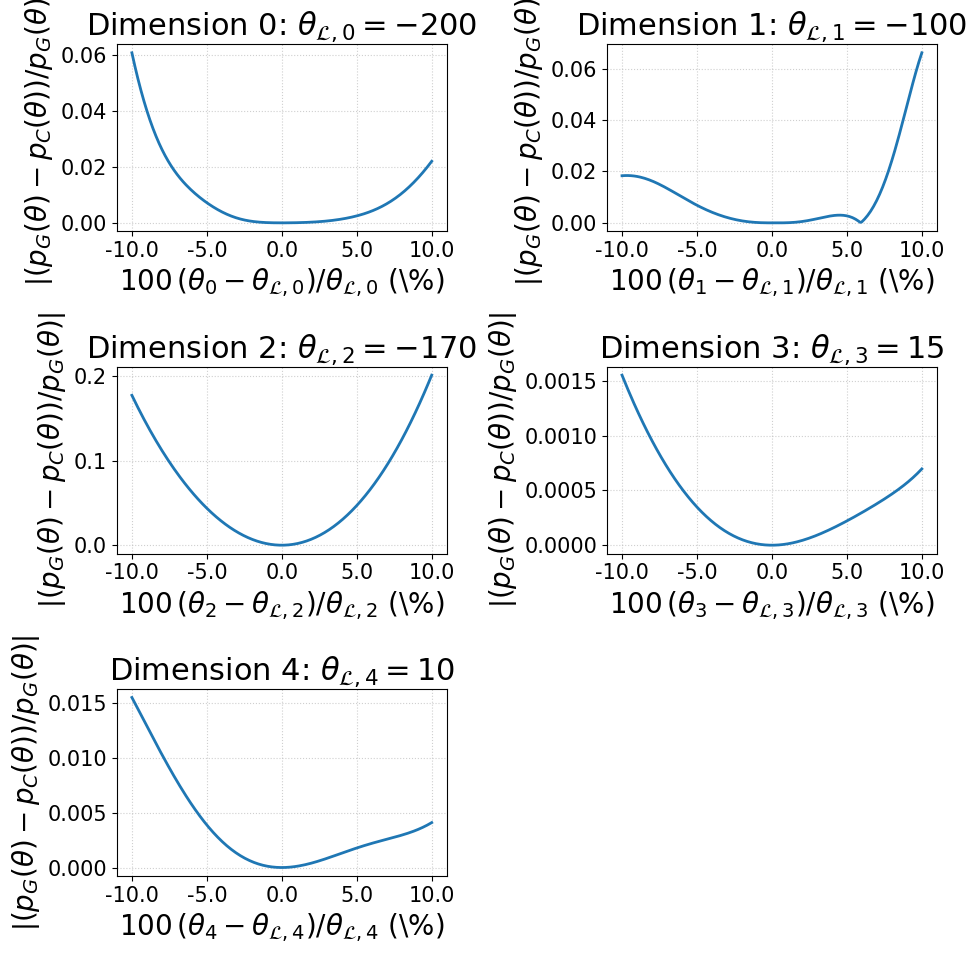

In [ ]:
fig_error = plt.figure(figsize=(10, 10))
grid = fig_error.add_gridspec(3, 2)
error_axes = [
    fig_error.add_subplot(grid[0, 0]),
    fig_error.add_subplot(grid[0, 1]),
    fig_error.add_subplot(grid[1, 0]),
    fig_error.add_subplot(grid[1, 1]),
    fig_error.add_subplot(grid[2, 0]),
]
fig_error.add_subplot(grid[2, 1]).axis("off")

for i, ax in enumerate(error_axes):
    delta_theta = np.zeros(N_desc)
    delta_theta[i] = 1.0
    compute_relative_cumulant_error(
        scores,
        fims,
        probs,
        delta_theta,
        theta_reference=theta_0[i],
        variation_percent_range=10.0,
        ax=ax,
    )
    ax.set_title(rf"Dimension {i}: $\theta_{{\mathcal{{L}},{i}}}={theta_0[i]}$")
    ax.set_xlabel(rf"$100\,(\theta_{i}-\theta_{{\mathcal{{L}},{i}}})/\theta_{{\mathcal{{L}},{i}}}$ (\%)")

fig_error.tight_layout()
fig_error.savefig("mb_cumulant_relative_error.png", dpi=300, bbox_inches="tight")